In [1]:
import mysql.connector
import pandas as pd
from matplotlib import pyplot as plt

import bt4301

bt4301.set_default_pandas_options(max_columns=50)
pd.set_option('display.float_format', lambda x: '%.2f' % x)

In [2]:
db_datawarehouse = mysql.connector.connect(
	host='localhost',
	user='bt4301',
	passwd='password',
	database='datawarehouse'
)

In [3]:
# retrieve sales by product and time dimensions

str_sql = '''
SELECT *
FROM sales
    INNER JOIN product ON sales.ProductID = product.ProductID
    INNER JOIN salesordertime ON sales.SalesOrderID = salesordertime.SalesOrderID
ORDER BY sales.SalesOrderID, sales.SalesOrderDetailID ASC
'''
df = pd.read_sql(sql=str_sql, con=db_datawarehouse)
df

/tmp/ipykernel_15309/2084397911.py:10: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(sql=str_sql, con=db_datawarehouse)


,index,SalesOrderID,SalesOrderDetailID,ProductID,OrderQty,UnitPrice,UnitPriceDiscount,LineTotal,CustomerID,index,ProductID,ProductNumber,Name,Color,StandardCost,ListPrice,Size,SizeUnitMeasureCode,Weight,WeightUnitMeasureCode,ProductLine,Class,Style,ProductModelName,ProductSubCategoryName,ProductCategoryName,index,SalesOrderID,OrderDate,OrderDateYear,OrderDateMonth,OrderDateDay,OrderDateDayOfWeek,OrderDateWeek
0,0,43697,353,749,1,3578.27,0.00,3578.27,21768,44,749,BK-R93R-62,"Road-150 Red, 62",Red,2171.29,3578.27,62,CM,15.00,LB,R,H,U,Road-150,Road Bikes,Bikes,0,43697,2005-07-01,2005,7,1,5,26
1,1,43698,354,773,1,3399.99,0.00,3399.99,28389,68,773,BK-M82S-44,"Mountain-100 Silver, 44",Silver,1912.15,3399.99,44,CM,21.13,LB,M,H,U,Mountain-100,Mountain Bikes,Bikes,1,43698,2005-07-01,2005,7,1,5,26
2,2,43699,355,773,1,3399.99,0.00,3399.99,25863,68,773,BK-M82S-44,"Mountain-100 Silver, 44",Silver,1912.15,3399.99,44,CM,21.13,LB,M,H,U,Mountain-100,Mountain Bikes,Bikes,2,43699,2005-07-01,2005,7,1,5,26
3,3,43700,356,767,1,699.10,0.00,699.10,14501,62,767,BK-R50B-62,"Road-650 Black, 62",Black,486.71,782.99,62,CM,20.00,LB,R,L,U,Road-650,Road Bikes,Bikes,3,43700,2005-07-01,2005,7,1,5,26
4,4,43701,357,773,1,3399.99,0.00,3399.99,11003,68,773,BK-M82S-44,"Mountain-100 Silver, 44",Silver,1912.15,3399.99,44,CM,21.13,LB,M,H,U,Mountain-100,Mountain Bikes,Bikes,4,43701,2005-07-01,2005,7,1,5,26
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
60393,60393,75122,121313,878,1,21.98,0.00,21.98,15868,173,878,FE-6654,Fender Set - Mountain,NaN,8.22,21.98,NaN,NaN,NaN,NaN,M,NaN,NaN,Fender Set - Mountain,Fenders,Accessories,27657,75122,2008-07-31,2008,7,31,4,30
60394,60394,75122,121314,712,1,8.99,0.00,8.99,15868,7,712,CA-1098,AWC Logo Cap,Multi,6.92,8.99,NaN,NaN,NaN,NaN,S,NaN,U,Cycling Cap,Caps,Clothing,27657,75122,2008-07-31,2008,7,31,4,30
60395,60395,75123,121315,878,1,21.98,0.00,21.98,18759,173,878,FE-6654,Fender Set - Mountain,NaN,8.22,21.98,NaN,NaN,NaN,NaN,M,NaN,NaN,Fender Set - Mountain,Fenders,Accessories,27658,75123,2008-07-31,2008,7,31,4,30
60396,60396,75123,121316,879,1,159.00,0.00,159.00,18759,174,879,ST-1401,All-Purpose Bike Stand,NaN,59.47,159.00,NaN,NaN,NaN,NaN,M,NaN,NaN,All-Purpose Bike Stand,Bike Stands,Accessories,27658,75123,2008-07-31,2008,7,31,4,30


In [4]:
# perform basic data profiling using pandas built-in support

bt4301.data_quality_report(df)

,index,SalesOrderID,SalesOrderDetailID,ProductID,OrderQty,UnitPrice,UnitPriceDiscount,LineTotal,CustomerID,index,ProductID,ProductNumber,Name,Color,StandardCost,ListPrice,Size,SizeUnitMeasureCode,Weight,WeightUnitMeasureCode,ProductLine,Class,Style,ProductModelName,ProductSubCategoryName,ProductCategoryName,index,SalesOrderID,OrderDate,OrderDateYear,OrderDateMonth,OrderDateDay,OrderDateDayOfWeek,OrderDateWeek
count,60398.00,60398.00,60398.00,60398.00,60398.00,60398.00,60398.00,60398.00,60398.00,60398.00,60398.00,60398,60398,31479,60398.00,60398.00,22849,15205,15205.00,15205,60398,21452,24306,60398,60398,60398,60398.00,60398.00,60398,60398.00,60398.00,60398.00,60398.00,60398.00
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,130,130,7,NaN,NaN,18,1,NaN,1,4,3,2,40,17,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,WB-H098,Water Bottle - 30 oz.,Black,NaN,NaN,M,CM,NaN,LB,S,H,U,Sport-100,Tires and Tubes,Accessories,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4244,4244,9843,NaN,NaN,2197,15205,NaN,15205,23358,10911,20425,6440,17332,36092,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,30198.50,61849.38,76723.96,852.06,1.00,486.09,0.00,486.09,18841.69,147.06,852.06,NaN,NaN,NaN,292.57,494.84,NaN,NaN,20.79,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15288.93,61849.38,2007-12-11 12:21:38.903937,2007.46,6.38,15.74,4.00,25.26
min,0.00,43697.00,353.00,707.00,1.00,2.29,0.00,2.29,11000.00,2.00,707.00,NaN,NaN,NaN,0.86,2.29,NaN,NaN,13.77,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.00,43697.00,2005-07-01 00:00:00,2005.00,1.00,1.00,1.00,0.00
25%,15099.25,55560.00,56765.25,782.00,1.00,7.95,0.00,7.95,14003.00,77.00,782.00,NaN,NaN,NaN,2.97,7.95,NaN,NaN,15.79,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9351.00,55560.00,2007-10-05 00:00:00,2007.00,3.00,8.00,2.00,13.00
50%,30198.50,62104.00,79192.50,872.00,1.00,29.99,0.00,29.99,18143.00,167.00,872.00,NaN,NaN,NaN,11.22,29.99,NaN,NaN,20.42,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15444.00,62104.00,2008-01-15 00:00:00,2008.00,6.00,16.00,4.00,24.00
75%,45297.75,68650.00,100354.75,922.00,1.00,539.99,0.00,539.99,23429.75,217.00,922.00,NaN,NaN,NaN,294.58,539.99,NaN,NaN,24.13,NaN,NaN,NaN,NaN,NaN,NaN,NaN,21546.00,68650.00,2008-04-20 00:00:00,2008.00,9.00,23.00,6.00,39.00
max,60397.00,75123.00,121317.00,999.00,1.00,3578.27,0.00,3578.27,29483.00,294.00,999.00,NaN,NaN,NaN,2171.29,3578.27,NaN,NaN,30.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,27658.00,75123.00,2008-07-31 00:00:00,2008.00,12.00,31.00,7.00,53.00


In [5]:
# analyse sales by order quantity

df_pivot = pd.pivot_table(df, values='OrderQty', index=['ProductCategoryName', 'ProductSubCategoryName', 'ProductModelName'], columns='OrderDateYear', aggfunc='sum')
df_pivot

OrderDateYear                                                            2005   2006    2007    2008
ProductCategoryName ProductSubCategoryName ProductModelName                                         
Accessories         Bike Racks             Hitch Rack - 4-Bike            NaN    NaN  137.00  191.00
                    Bike Stands            All-Purpose Bike Stand         NaN    NaN  119.00  130.00
                    Bottles and Cages      Mountain Bottle Cage           NaN    NaN  824.00 1201.00
                                           Road Bottle Cage               NaN    NaN  707.00 1005.00
                                           Water Bottle                   NaN    NaN 1742.00 2502.00
                    Cleaners               Bike Wash                      NaN    NaN  383.00  525.00
                    Fenders                Fender Set - Mountain          NaN    NaN  883.00 1238.00
                    Helmets                Sport-100                      NaN    NaN 2646.00 3794.00
                    Hydration Packs        Hydration Pack                 NaN    NaN  305.00  428.00
                    Tires and Tubes        HL Mountain Tire               NaN    NaN  580.00  816.00
                                           HL Road Tire                   NaN    NaN  395.00  463.00
                                           LL Mountain Tire               NaN    NaN  363.00  499.00
                                           LL Road Tire                   NaN    NaN  436.00  608.00
                                           ML Mountain Tire               NaN    NaN  500.00  661.00
                                           ML Road Tire                   NaN    NaN  393.00  533.00
                                           Mountain Tire Tube             NaN    NaN 1313.00 1782.00
                                           Patch kit                      NaN    NaN 1356.00 1835.00
                                           Road Tire Tube                 NaN    NaN  999.00 1377.00
                                           Touring Tire                   NaN    NaN  353.00  582.00
                                           Touring Tire Tube              NaN    NaN  591.00  897.00
Bikes               Mountain Bikes         Mountain-100                173.00 223.00     NaN     NaN
                                           Mountain-200                   NaN 392.00 1687.00 1473.00
                                           Mountain-400-W                 NaN    NaN  207.00  336.00
                                           Mountain-500                   NaN    NaN  194.00  285.00
                    Road Bikes             Road-150                    727.00 824.00     NaN     NaN
                                           Road-250                       NaN 691.00  911.00  301.00
                                           Road-350-W                     NaN    NaN  318.00  611.00
                                           Road-550-W                     NaN 146.00  626.00  618.00
                                           Road-650                    113.00 401.00  338.00     NaN
                                           Road-750                       NaN    NaN  604.00  839.00
                    Touring Bikes          Touring-1000                   NaN    NaN  444.00  811.00
                                           Touring-2000                   NaN    NaN  161.00  211.00
                                           Touring-3000                   NaN    NaN  220.00  320.00
Clothing            Caps                   Cycling Cap                    NaN    NaN  885.00 1305.00
                    Gloves                 Half-Finger Gloves             NaN    NaN  581.00  849.00
                    Jerseys                Long-Sleeve Logo Jersey        NaN    NaN  683.00 1053.00
                                           Short-Sleeve Classic Jersey    NaN    NaN  671.00  925.00
                    Shorts                 Women's Mountain S

<Axes: xlabel='ProductCategoryName,ProductSubCategoryName,ProductModelName'>

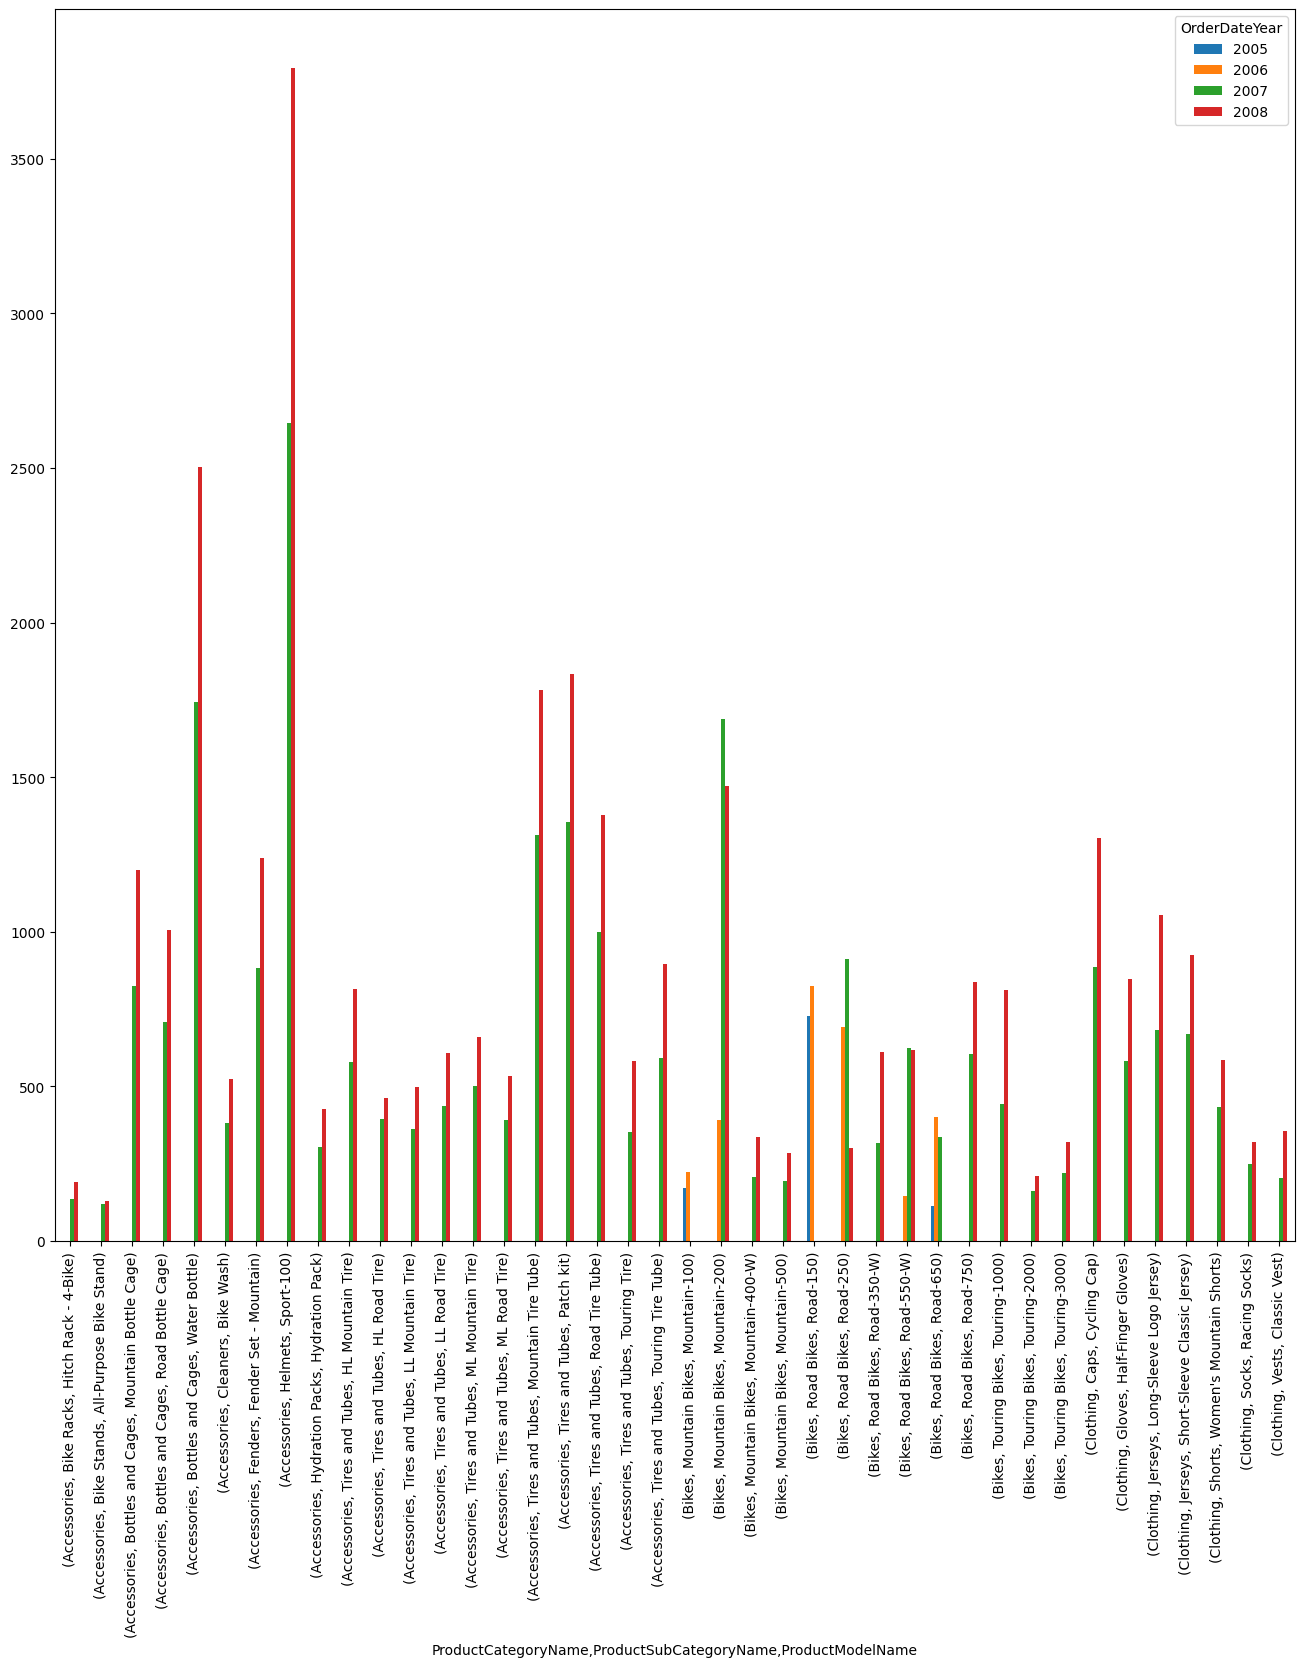

In [6]:
df_pivot.plot(kind='bar', figsize=(16,16))

In [7]:
# analyse sales by order value

df_pivot = pd.pivot_table(df, values='LineTotal', index=['ProductCategoryName', 'ProductSubCategoryName', 'ProductModelName'], columns='OrderDateYear', aggfunc='sum')
df_pivot

OrderDateYear                                                                2005       2006       2007       2008
ProductCategoryName ProductSubCategoryName ProductModelName                                                       
Accessories         Bike Racks             Hitch Rack - 4-Bike                NaN        NaN   16440.00   22920.00
                    Bike Stands            All-Purpose Bike Stand             NaN        NaN   18921.00   20670.00
                    Bottles and Cages      Mountain Bottle Cage               NaN        NaN    8231.76   11997.99
                                           Road Bottle Cage                   NaN        NaN    6355.93    9034.95
                                           Water Bottle                       NaN        NaN    8692.58   12484.98
                    Cleaners               Bike Wash                          NaN        NaN    3044.85    4173.75
                    Fenders                Fender Set - Mountain              NaN        NaN   19408.34   27211.24
                    Helmets                Sport-100                          NaN        NaN   92583.54  132752.06
                    Hydration Packs        Hydration Pack                     NaN        NaN   16771.95   23535.72
                    Tires and Tubes        HL Mountain Tire                   NaN        NaN   20300.00   28560.00
                                           HL Road Tire                       NaN        NaN   12877.00   15093.80
                                           LL Mountain Tire                   NaN        NaN    9071.37   12470.01
                                           LL Road Tire                       NaN        NaN    9369.64   13065.92
                                           ML Mountain Tire                   NaN        NaN   14995.00   19823.39
                                           ML Road Tire                       NaN        NaN    9821.07   13319.67
                                           Mountain Tire Tube                 NaN        NaN    6551.87    8892.18
                                           Patch kit                          NaN        NaN    3105.24    4202.15
                                           Road Tire Tube                     NaN        NaN    3986.01    5494.23
                                           Touring Tire                       NaN        NaN   10233.47   16872.18
                                           Touring Tire Tube                  NaN        NaN    2949.09    4476.03
Bikes               Mountain Bikes         Mountain-100                 585973.27  755147.77        NaN        NaN
                                           Mountain-200                       NaN  807308.99 3723270.99 3398895.27
                                           Mountain-400-W                     NaN        NaN  159284.43  258548.64
                                           Mountain-500                       NaN        NaN  107083.06  157247.15
                    Road Bikes             Road-150                    2601402.29 2948494.48        NaN        NaN
                                           Road-250                           NaN 1571597.62 2144214.15  735448.35
                                           Road-350-W                         NaN        NaN  540914.82 1039304.89
                                           Road-550-W                         NaN  146063.88  676095.66  692462.82
                                           Road-650                      78998.10  301730.79  264650.62        NaN
                                           Road-750                           NaN        NaN  326153.96  453051.61
                    Touring Bikes          Touring-1000                       NaN        NaN 1058527.08 1933480.77
                                           Touring-2000                       NaN        NaN  195590.85  256333.35
                                           Touring-3000                       NaN        N

<Axes: xlabel='ProductCategoryName,ProductSubCategoryName,ProductModelName'>

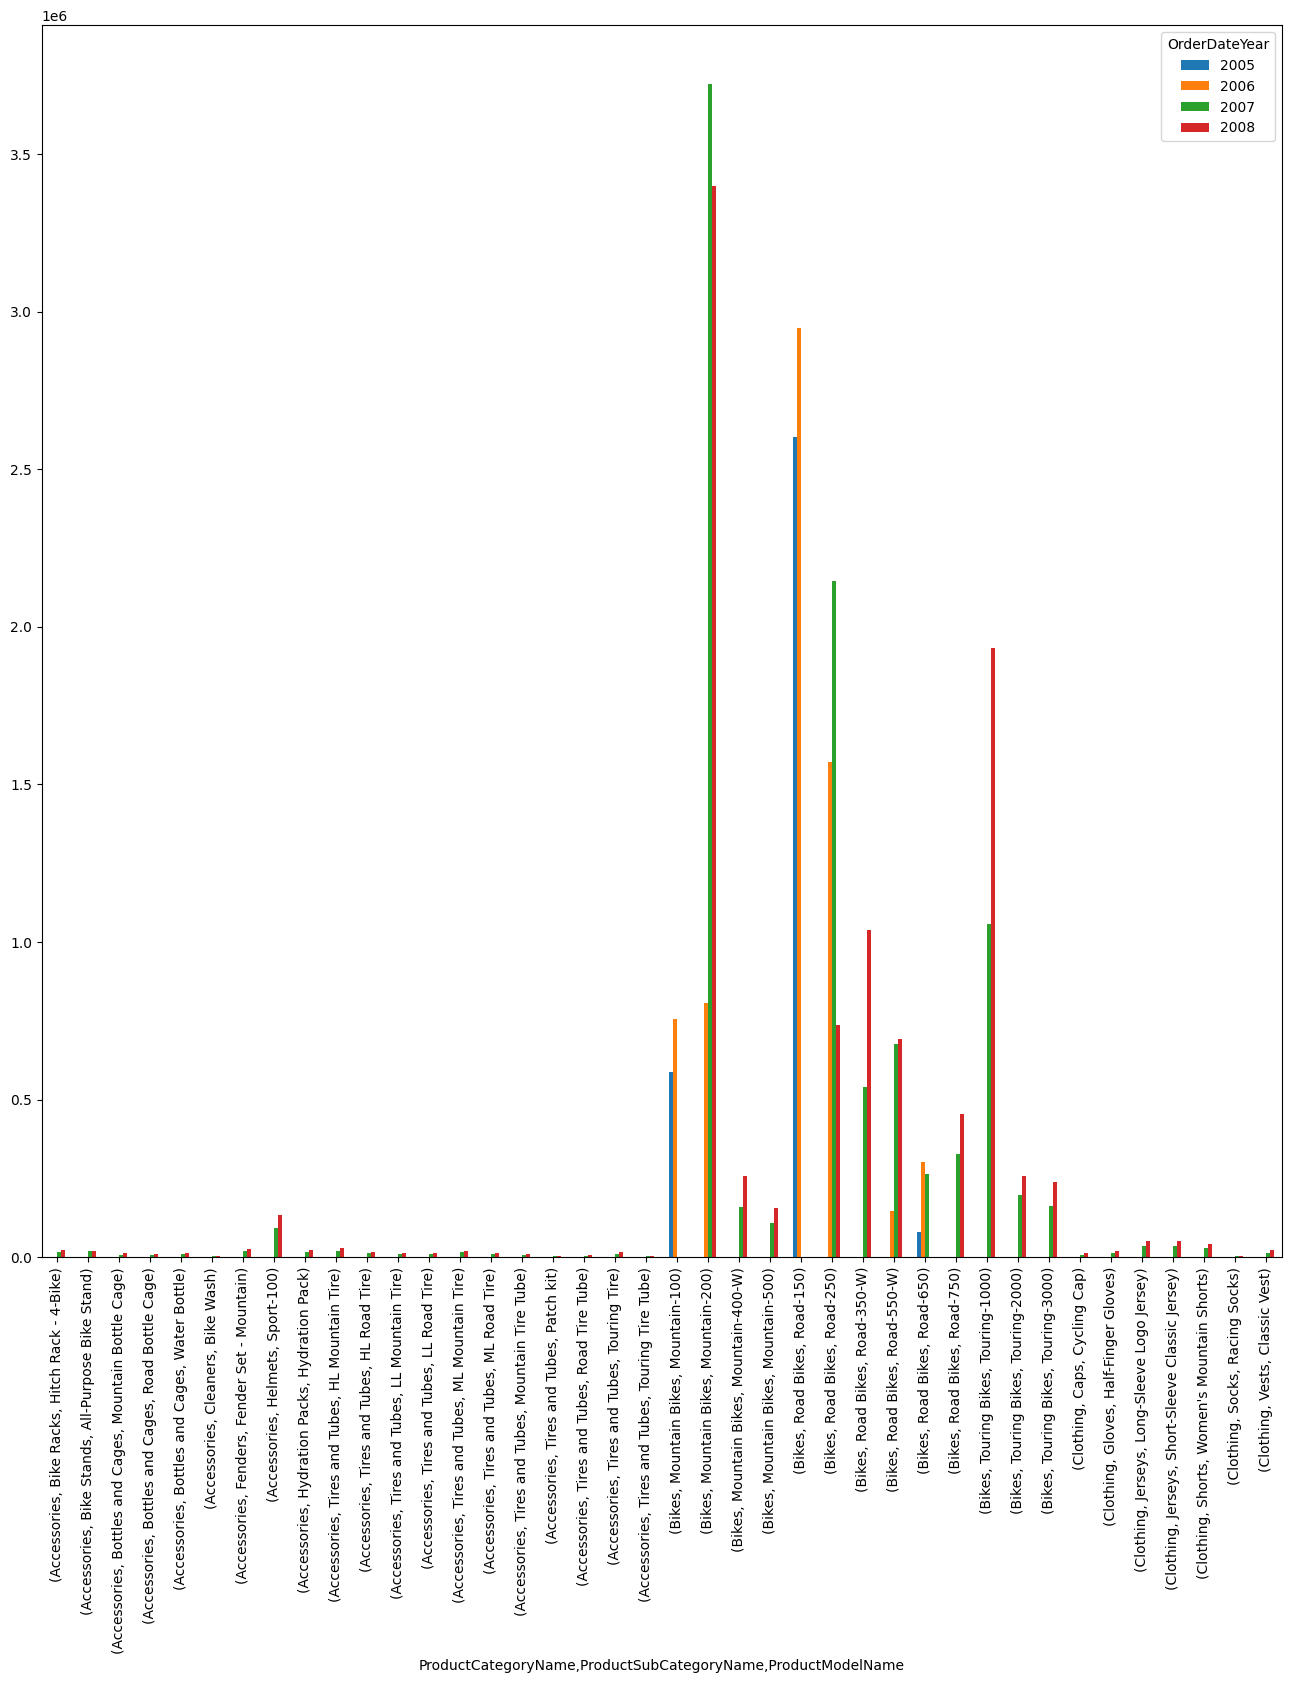

In [8]:
df_pivot.plot(kind='bar', figsize=(16,16))

In [9]:
db_datawarehouse.commit()
db_datawarehouse.close()